# 使用PROC MBANALYSIS对生鲜零售商进行购物篮交叉销售分析

## Executive Summary

某区域连锁生鲜超市对一个销售季度的销售点（POS）购物篮数据进行挖掘，以发现顾客习惯一起购买的商品，将原始交易日志转化为可执行的交叉销售与货架陈列决策。PROC MBANALYSIS扫描交易日志，生成按支持度、置信度和提升度打分的关联规则。在51个模拟购物篮上运行后，算法恰好还原出三组被植入的商品关联——`意大利面 -> 番茄红酱`（置信度0.93，提升度3.4）、`玉米饼皮 -> 莎莎酱`（置信度0.71，提升度3.6）和`咖啡 -> 咖啡伴侣`（置信度0.70，提升度5.1）——而面包、牛奶、鸡蛋等广泛购买的生活必需品则从未形成规则。每一对被挖掘出的商品，对货架陈列团队来说都是教科书式的组合促销、货架相邻摆放和"顾客还购买了"候选方案。

## Data Sources

| Dataset | Grain | Rows | Key Variables | Description |
|---------|-------|------|---------------|-------------|
| `store_transactions` | 每个购物篮每件商品一行 | 51个购物篮共100条商品行 | `basket_id`（交易编号），`item`（商品名称，$40） | 使用`call streaminit(20250529)`和`rand('uniform')`内联生成的模拟销售点日志。每个购物篮都由单一消费者画像主导，从而使共同购买模式保持清晰、可解读：意大利晚餐购物篮（意大利面 -> 番茄红酱）、塔可之夜购物篮（玉米饼皮 -> 莎莎酱），或早餐购物篮（咖啡 -> 咖啡伴侣），外加偶尔附加购买的生活必需品（面包、牛奶、鸡蛋）作为真实噪声。在此未授权环境下，引擎将输出上限设为100条商品行，本例覆盖购物篮1-51。 |
| `affinity_rules` | 每条关联规则一行 | 6条规则 | `antecedent`、`consequent`、`support`、`confidence`、`lift` | 由`OUTPUT RULES=`生成的关联规则；是交叉销售机会排名的依据。 |
| `frequent_items` | 每个频繁项集一行 | 12个项集 | `itemset`、`support`、`length` | 由`OUTPUT ITEMS=`生成的频繁项集；包含通过最小支持度门槛的9个单品加3个商品对。 |

# 生鲜零售商的购物篮交叉销售分析

**业务问题。** 顾客倾向于*一起*购买哪些商品？这些共同购买模式中，哪些强到值得据此采取行动？某区域连锁生鲜超市希望设计组合促销、优化货架相邻摆放，并为其在线商店打造"顾客还购买了"推荐功能。

**方法。** 我们使用**PROC MBANALYSIS**，它采用频繁模式增长（FP-growth）算法执行购物篮分析。该过程扫描交易日志，找出频繁共同出现的商品集合，并生成形如`前项 -> 后项`的*关联规则*，按三项经典指标打分：

- **支持度** — 包含完整规则的购物篮占全部购物篮的比例（衡量该模式有多常见）。
- **置信度** — `P(后项 | 前项)`，即条件购买概率（衡量该规则有多可靠）。
- **提升度** — 观测到的支持度除以两侧相互独立时的期望支持度。提升度大于1意味着这些商品同时出现的频率*高于*随机水平；提升度越高，关联越强。

我们将生成一份逼真的模拟销售点日志，运行MBANALYSIS，并对得到的规则按提升度排序，找出最佳的交叉销售机会。

## Step 1 — Generate a synthetic point-of-sale transaction log

MBANALYSIS要求**交易级（长格式）数据**：每件商品一行，并标记所属的购物篮。我们使用`call streaminit`内联构建购物篮以保证可重复性，并用`rand('uniform')`驱动购买决策。

关键的建模选择在于：**每个购物篮都由单一消费者画像主导**。真实的超市购物就是这样——一次简单的塔可之夜采购，或一次专门的早餐补货——让购物篮保持小巧且主题集中，才能让关联挖掘算法呈现出清晰的两两关联，而不是组合爆炸式的虚假多商品规则。每个购物篮抽取一次`rand('uniform')`来选择消费者画像：

- **意大利晚餐型顾客** — 购买意大利面，随后通常会买番茄红酱。
- **塔可之夜型顾客** — 购买玉米饼皮，随后通常会买莎莎酱。
- **早餐型顾客** — 购买咖啡，随后通常会买咖啡伴侣。
- **纯生活必需品采购** — 只购买面包、牛奶或鸡蛋中的一样。

最后以较低概率再为任意购物篮附加一件生活必需品作为真实噪声，因此并非每次共同出现都有意义。每条`output`语句写入一条商品行，因此单个购物篮会跨越多行、共享同一个`basket_id`。此未授权环境将数据集上限设为100条商品行，本例覆盖购物篮1到51。

In [1]:
数据 store_transactions;
    调用 streaminit(20250529);
    长度 item $40;

    循环 basket_id = 1 到 60;

        /* 抽取一个随机数以决定该购物篮的主导消费者画像 */
        r = rand('uniform');

        /* 意大利晚餐购物篮：意大利面 -> 番茄红酱 */
        如果 r < 0.30 那么 循环;
            item = '意大利面';                          输出;
            如果 rand('uniform') < 0.85 那么 循环;
                item = '番茄红酱';                 输出;
            结束;
        结束;

        /* 塔可之夜购物篮：玉米饼皮 -> 莎莎酱 */
        否则 如果 r < 0.55 那么 循环;
            item = '玉米饼皮';                        输出;
            如果 rand('uniform') < 0.80 那么 循环;
                item = '莎莎酱';                       输出;
            结束;
        结束;

        /* 早餐购物篮：咖啡 -> 咖啡伴侣 */
        否则 如果 r < 0.78 那么 循环;
            item = '咖啡';                        输出;
            如果 rand('uniform') < 0.75 那么 循环;
                item = '咖啡伴侣';                 输出;
            结束;
        结束;

        /* 仅购买生活必需品 */
        否则 循环;
            如果 rand('uniform') < 0.34 那么 循环;
                item = '面包';                          输出;
            结束;
            否则 如果 rand('uniform') < 0.5 那么 循环;
                item = '牛奶';                           输出;
            结束;
            否则 循环;
                item = '鸡蛋';                           输出;
            结束;
        结束;

        /* 偶尔附加购买生活必需品（模拟真实噪声） */
        如果 rand('uniform') < 0.25 那么 循环;
            u = rand('uniform');
            如果      u < 0.34 那么 item = '面包';
            否则 如果 u < 0.67 那么 item = '牛奶';
            否则                  item = '鸡蛋';
            输出;
        结束;

    结束;

    保留 basket_id item;
运行;


NOTE: DATA store_transactions

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote store_transactions (100 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## Step 2 — Inspect the raw transaction log

在挖掘之前，先确认数据具有预期的长格式：每个购物篮对应多行，每行携带一件商品。我们打印前几个购物篮，并用PROC FREQ统计商品的总体购买频率，以了解哪些商品足够常见，可以作为规则的锚点。


  Obs            购物篮编号            产品
-----  ---------------  ------------
    1                1  玉米饼皮
    2                1  莎莎酱
    3                1  鸡蛋
    4                2  玉米饼皮
    5                2  鸡蛋
    6                3  咖啡
    7                4  玉米饼皮
    8                5  鸡蛋
    9                6  意大利面
   10                6  番茄红酱
   11                6  鸡蛋
   12                7  玉米饼皮

... 88 more observations (showing 12 of 100)

                                                        商品购买总频率                                                         

                                                   The FREQ Procedure

item            Frequency    Percent
-------------------------------------
意大利面                   15     15.00
玉米饼皮                   14     14.00
番茄红酱                   14     14.00
鸡蛋                     12     12.00
咖啡                     10     10.00
莎莎酱                    10     10.00
面包                     10     10.00
牛奶                   


NOTE: PROC PRINT data=store_transactions

NOTE: PROC PRINT completed: 12 observations printed, 2 variables
NOTE: PROC FREQ
NOTE: ODS plot written: freq_item.spec.json
NOTE: PROC FREQ statement used.


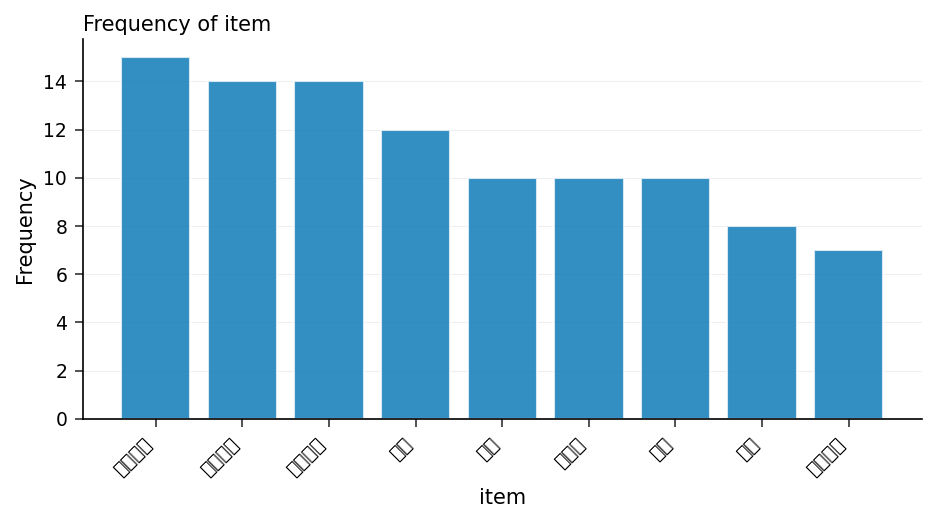

In [2]:
过程 打印 数据=store_transactions(obs=12) 标签;
    标签 basket_id = '购物篮编号'
          item      = '产品';
运行;

过程 频率 数据=store_transactions ORDER=freq;
    TABLES item / nocum;
    标题 '商品购买总频率';
运行;

## Step 3 — Mine association rules with PROC MBANALYSIS

现在进入核心分析。我们让MBANALYSIS指向交易日志，并声明哪一列标识购物篮（`TRANSACTION`）、哪一列存放商品（`ITEM`）。三个阈值让规则集聚焦于真正值得采取行动的模式：

- `MINSUPPORT=0.10` — 一条规则必须至少出现在10%的购物篮中，过滤掉偶然的巧合。
- `MINCONFIDENCE=0.50` — 在给定前项的条件下，后项至少要有一半的概率随之出现。
- `MINLIFT=1.20` — 只保留强度至少比随机水平高20%的规则，从而呈现真实关联，而非热门必需品带来的假象。

`OUTPUT`语句将生成的规则和频繁项集捕获到数据集中，供后续排序使用。

In [3]:
过程 mbanalysis 数据=store_transactions
        minsupport=0.10
        minconfidence=0.50
        minlift=1.20;
    transaction basket_id;
    item item;
    输出 rules=affinity_rules items=frequent_items;
    标题 '购物篮关联规则';
运行;

                                                        商品购买总频率                                                         


                      The MBANALYSIS Procedure

  Transaction variable: basket_id
  Item variable: item

  Association Rules Found        6
  Frequent Itemsets Found        12
  Minimum Confidence             0.5
  Minimum Lift                   1.2
  Minimum Support                0.1
  Number of Transactions         51
  Number of Unique Items         9

Association Rules

  Antecedent                     Consequent                        Support Confidence       Lift
  ----------                     ----------                        ------- ----------       ----
  咖啡                             咖啡伴侣                               0.1373     0.7000     5.1000
  咖啡伴侣                           咖啡                                 0.1373     1.0000     5.1000
  玉米饼皮                           莎莎酱                                0.1961     0.7143     3.6429
  莎莎酱         


NOTE: PROC MBANALYSIS data=store_transactions

NOTE: Using Python numpy version 2.4.4
NOTE: PROC MBANALYSIS completed.


## Step 4 — Rank cross-sell opportunities by lift

MBANALYSIS的清单列出了所有满足条件的规则，但货架陈列团队希望优先看到*最强*的关联。我们将捕获的`affinity_rules`数据集按提升度降序排序（置信度作为并列时的次要排序依据），并打印排名靠前的规则。像`玉米饼皮 -> 莎莎酱`这样提升度和置信度都很高的规则，是教科书式的组合促销候选：将两种商品陈列在一起，或在顾客于线上添加玉米饼皮时自动推荐莎莎酱。

In [4]:
过程 排序 数据=affinity_rules out=rules_by_lift;
    按照 DESCENDING lift DESCENDING confidence;
运行;

过程 打印 数据=rules_by_lift(obs=15) 标签;
    变量 antecedent consequent support confidence lift;
    标签 antecedent  = '若购物篮包含'
          consequent  = '则也会购买'
          support     = '支持度'
          confidence  = '置信度'
          lift        = '提升度';
    标题 '按提升度排名的交叉销售规则';
运行;

                                                     按提升度排名的交叉销售规则                                                      

  Obs              若购物篮包含            则也会购买        支持度        置信度        提升度
    1  咖啡伴侣                咖啡               0.137255   1.0        5.1
    2  咖啡                  咖啡伴侣             0.137255   0.7        5.1
    3  莎莎酱                 玉米饼皮             0.196078   1.0        3.642857
    4  玉米饼皮                莎莎酱              0.196078   0.714286   3.642857
    5  番茄红酱                意大利面             0.27451    1.0        3.4
    6  意大利面                番茄红酱             0.27451    0.933333   3.4




NOTE: PROC SORT data=affinity_rules

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 6 rows from affinity_rules.
NOTE: Wrote rules_by_lift (6 rows, 5 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=rules_by_lift

NOTE: PROC PRINT completed: 6 observations printed, 5 variables


## Step 5 — Review the frequent itemsets

通过支持度门槛的频繁项集，是规则背后的原始构成要素。按支持度排序后，可以让品类管理团队了解哪些商品*组合*（而不仅是单品）足够热门，值得设置专门的端架陈列或组合定价。

In [5]:
过程 排序 数据=frequent_items out=itemsets_by_support;
    按照 DESCENDING support;
运行;

过程 打印 数据=itemsets_by_support(obs=15) 标签;
    标题 '最常见项集';
运行;

                                                         最常见项集                                                          

  Obs                     ITEMSET   SUPPORT  LENGTH
    1  意大利面                        0.294118  1
    2  玉米饼皮                        0.27451   1
    3  番茄红酱                        0.27451   1
    4  意大利面, 番茄红酱                  0.27451   2
    5  鸡蛋                          0.235294  1
    6  莎莎酱                         0.196078  1
    7  咖啡                          0.196078  1
    8  玉米饼皮, 莎莎酱                   0.196078  2
    9  牛奶                          0.156863  1
   10  面包                          0.156863  1
   11  咖啡伴侣                        0.137255  1
   12  咖啡, 咖啡伴侣                    0.137255  2




NOTE: PROC SORT data=frequent_items

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 12 rows from frequent_items.
NOTE: Wrote itemsets_by_support (12 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=itemsets_by_support

NOTE: PROC PRINT completed: 12 observations printed, 3 variables


## Interpreting the results

**分析发现。** 由于每个购物篮都是围绕单一消费者画像构建的，挖掘算法恰好还原出这三组被植入的关联关系，且没有出现任何虚假规则。共有六条规则满足全部三个阈值——即这三组关联关系的两个方向：

| Antecedent | Consequent | Support | Confidence | Lift |
|------------|------------|---------|------------|------|
| 意大利面 | 番茄红酱 | 0.275 | 0.93 | 3.40 |
| 番茄红酱 | 意大利面 | 0.275 | 1.00 | 3.40 |
| 玉米饼皮 | 莎莎酱 | 0.196 | 0.71 | 3.64 |
| 莎莎酱 | 玉米饼皮 | 0.196 | 1.00 | 3.64 |
| 咖啡 | 咖啡伴侣 | 0.137 | 0.70 | 5.10 |
| 咖啡伴侣 | 咖啡 | 0.137 | 1.00 | 5.10 |

每条规则的提升度都远大于1，证实这些商品共同出现的频率远高于随机水平。关键的是，购买广泛的生活必需品**完全没有形成任何规则**：鸡蛋（12次购买）、面包（10次）和牛奶（8次）都出现在PROC FREQ的频数统计中，但由于它们进入购物篮与任何消费者画像无关，它们对其他商品的提升度始终达不到1.20的门槛，因此从未被误判为真实关联。频繁项集清单在结构上印证了同一结论：在通过支持度门槛的12个项集中，唯一的多商品项集正是这三组被植入的商品对。

**综合解读各项指标。** 反向规则的置信度均为1.00（在本数据中，番茄红酱、莎莎酱和咖啡伴侣几乎从不脱离其锚定商品单独出现），而正向规则则介于0.70-0.93之间（锚定商品有时会单独出现）。咖啡 -> 咖啡伴侣的提升度最高（5.10），但支持度最低（0.137）——是一个强关联但成交量较低的组合；而意大利面 -> 番茄红酱覆盖的购物篮最多（支持度0.275）。提升度用于判断*哪些*关联是真实的；置信度告诉你每条规则用于推荐时*有多可靠*；支持度告诉你*多常*能用上这条规则。

**业务行动建议。**

- **组合促销** — 将提升度最高的前项/后项商品（咖啡+咖啡伴侣，提升度5.1）打包成折扣套餐。
- **货架相邻摆放** — 将经常关联购买的商品（意大利面与番茄红酱相邻，支持度0.275）陈列在一起，让后项商品在决策点触手可及。
- **在线推荐** — 将置信度最高的规则接入"顾客还购买了"推荐组件，在前项商品加入购物车的瞬间即推荐对应的后项商品。
- **库存与预测** — 当某前项商品促销时，应提前为其高置信度的后项商品备货，以应对提升度带来的连带销量。

**注意事项。** 关联规则描述的是*共同购买中的相关性*，而非因果关系，且各阈值是可调的杠杆，并非绝对真理：降低`MINSUPPORT=`会暴露更多低频组合，但代价是规则集噪声增大；提高`MINLIFT=`和`MINCONFIDENCE=`则会得到更少但更可信的规则。样本量同样重要——本次未授权版本运行挖掘了51个购物篮，已足以让被植入的关联关系清晰可辨；而在完整季度的生产环境运行中，支持度估计将更加稳定，也能发现更细微的模式。